## Calibrating SoilNet for Conformal Horizon Classification

In [1]:
import os
os.chdir('../../../')
!pwd

/mnt/KInsektDaten/teo


In [2]:
import sys
sys.path.append('./BGR')
import numpy as np
import torch
import matplotlib.pyplot as plt
from bgr.soil.data.horizon_tabular_data import HorizonDataProcessor

In [3]:
dataprocessor = HorizonDataProcessor(label_embeddings_path='./BGR/label_embeddings/all_horizons_embeddings_thirds.pickle')
df = dataprocessor.load_processed_data()

train_df, val_df, calib_df, test_df = dataprocessor.multi_label_stratified_shuffle_split_calibrated(df, train_val_calib_test_frac=[0.6, 0.2, 0.1, 0.1], random_state=2025)

In [4]:
#soilnet_path = './BGR/models/end2ends/linear_decreasing_teacher/end2end_lstm_resnet_embed_2025-05-13_12-14-11/model.pt'
soilnet_path = './BGR/models/end2ends/linear_decreasing_teacher/end2end_lstm_resnet_2025-05-13_18-05-30/model.pt'
output_shape = np.shape(dataprocessor.embeddings_dict['embedding']) # dimension of embeddings or number of classes
device = 'cuda:0'

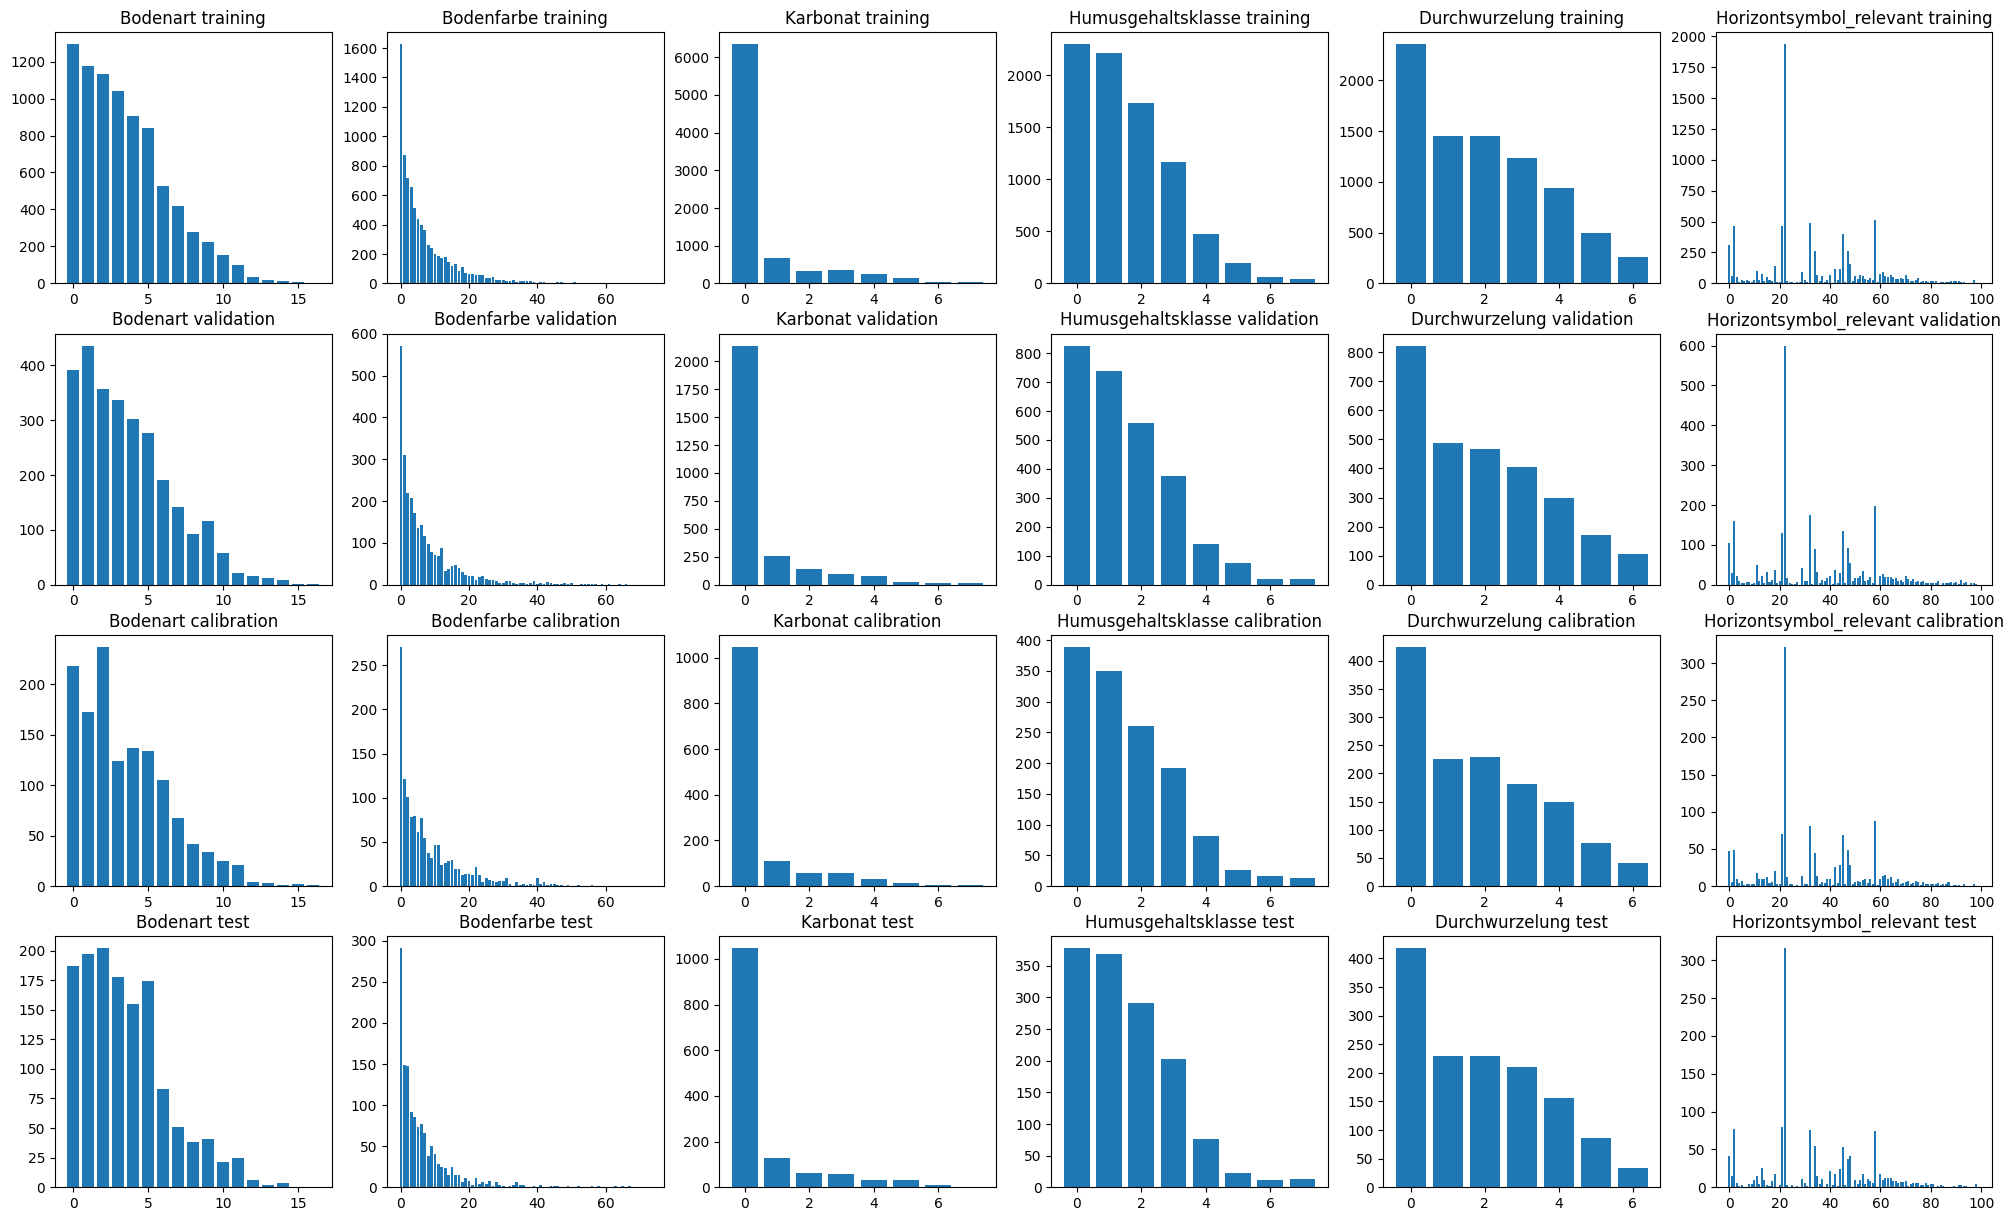

In [5]:
plt.figure(figsize=(25, 15))
for i, tab_feature in enumerate(list(dataprocessor.stratified_split_targets)):
    if tab_feature == 'Horizontsymbol_relevant':
        num_cls = output_shape[0]
    else:
        num_cls = dataprocessor.tabulars_output_dim_dict[tab_feature]

    counts_train = train_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)
    counts_val   = val_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)
    counts_calib = calib_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)
    counts_test  = test_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)

    plt.subplot(4, 6, i + 1)
    plt.bar(list(range(num_cls)), list(counts_train.values))
    plt.title(tab_feature + ' training')
    plt.subplot(4, 6, i + 7)
    plt.bar(list(range(num_cls)), list(counts_val.values))
    plt.title(tab_feature + ' validation')
    plt.subplot(4, 6, i + 13)
    plt.bar(list(range(num_cls)), list(counts_calib.values))
    plt.title(tab_feature + ' calibration')
    plt.subplot(4, 6, i + 19)
    plt.bar(list(range(num_cls)), list(counts_test.values))
    plt.title(tab_feature + ' test')
plt.show()

In [6]:
from bgr.soil.modelling.soilnet import SoilNet_LSTM

soilnet = SoilNet_LSTM(
            # Parameters for image encoder, geotemp encoder and depth predictor:
            geo_temp_input_dim        = len(dataprocessor.geotemp_img_infos) - 2, # without index and img path
            geo_temp_output_dim       = 256,
            image_encoder_output_dim  = 512,
            max_seq_len               = 8,
            stop_token                = 1.0,
            depth_rnn_hidden_dim      = 256,
            img_patch_size            = 512,
            segments_random_patches   = True, # True = use ResNet, False = use custom CNN
            num_patches_per_segment   = 8,
            segment_random_patch_size = 224,
            
            # Parameters for tabular predictors:
            tabular_output_dim_dict    = dataprocessor.tabulars_output_dim_dict,
            segment_encoder_output_dim = 512,
            tab_rnn_hidden_dim         = 1024,
            tab_num_lstm_layers        = 2,
            
            # Parameters for horizon predictor:
            segments_tabular_output_dim = 256,
            embedding_dim               = output_shape[1] if 'embed' in soilnet_path else output_shape[0],
            
            # Parameters for the model:
            teacher_forcing_stop_epoch  = -1, # no teacher forcing when doing only inference
            teacher_forcing_approach    = 'linear'
        )

soilnet.load_state_dict(torch.load(soilnet_path, map_location=torch.device(device)))

<All keys matched successfully>

In [7]:
from bgr.soil.data.datasets import ImageTabularEnd2EndDataset
import torchvision.transforms as transforms

subsets = []
for subset_df in [calib_df, test_df]:
    subset = ImageTabularEnd2EndDataset(
        dataframe=subset_df,
        normalize=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Normalize with ImageNet statistics
            ]),
        label_column='Horizontsymbol_relevant',
        geotemp_columns=dataprocessor.geotemp_img_infos[:-1], # without img path
        tab_num_columns=['Steine'],
        tab_categ_columns={key : value 
                for key, value in dataprocessor.tabulars_output_dim_dict.items() 
                    if key in [
                            'Bodenart',
                            'Bodenfarbe',
                            'Karbonat',
                            'Humusgehaltsklasse',
                            'Durchwurzelung'
                        ]
            }
    )
    subsets.append(subset)

calib_dataset, test_dataset = subsets

In [8]:
calib_loader = calib_dataset.to_dataloader(batch_size = 8, shuffle = True, num_workers = 4, drop_last=True)
test_loader  = test_dataset.to_dataloader(batch_size = 8, shuffle = True, num_workers = 4, drop_last=True)

In [9]:
soilnet.to(device)
soilnet.eval()
all_pred_depths, all_true_depths   = [], []
all_pred_logits, all_true_hor_inds = [], []
for batch in calib_loader:
    padded_images, image_mask, geotemp_features, padded_true_depths, padded_segments_tabulars_labels, padded_true_horizon_indices = batch
    padded_images, image_mask, geotemp_features, padded_true_depths, padded_segments_tabulars_labels, padded_true_horizon_indices = (
        padded_images.to(device),
        image_mask.to(device),
        geotemp_features.to(device),
        padded_true_depths.to(device),
        padded_segments_tabulars_labels.to(device),
        padded_true_horizon_indices.to(device)
    )
    
    with torch.no_grad():
        
        # Mask for valid indices
        mask = padded_true_horizon_indices != -1
        
        ### Predictions for all (sub)tasks
        padded_pred_depths, padded_pred_tabulars, padded_pred_logits = soilnet(
            padded_images,
            image_mask,
            geotemp_features[:, 1:], # 'index' column not used in model
            #padded_true_depths,             # use predicted depths when not training 
            #padded_segments_tabulars_labels # use predicted tabulars when not training
        )
        
        # Store predicted horizon logits and true indices
        pred_logits = padded_pred_logits.view(-1, padded_pred_logits.size(-1))[mask.view(-1)]  # Apply mask
        all_pred_logits.append(pred_logits.cpu().numpy())
        
        true_horizon_indices = padded_true_horizon_indices.view(-1)[padded_true_horizon_indices.view(-1) != -1]
        all_true_hor_inds.append(true_horizon_indices.cpu().numpy())
        
        # Store predicted and true depths
        all_pred_depths.append(padded_pred_depths.cpu().numpy())
        all_true_depths.append(padded_true_depths.cpu().numpy())

### Calibrate Task 1

In [10]:
all_pred_depths = np.concatenate(all_pred_depths, axis=0)
all_pred_depths.shape

(328, 8)

In [11]:
all_true_depths = np.concatenate(all_true_depths, axis=0)
all_true_depths.shape

(328, 8)

In [ ]:
trimmed_true_depths = []
for sublist in all_true_depths.tolist():
    # Remove trailing 1.0's, keep one if present
    i = len(sublist) - 1
    while i > 0 and sublist[i] == 1.0 and sublist[i-1] == 1.0:
        i -= 1
    trimmed_true_depths.append(sublist[:i+1])
#trimmed_true_depths

In [13]:
# Remove stop tokens from predicted depths as well
trimmed_pred_depths = []
for i in range(len(all_pred_depths)):
    trimmed_pred_depths.append(all_pred_depths[i][:len(trimmed_true_depths[i])].tolist())
#trimmed_pred_depths

In [14]:
# Unroll the list of lists
trimmed_pred_depths_stacked = torch.tensor([item for sublist in trimmed_pred_depths for item in sublist])
trimmed_true_depths_stacked = torch.tensor([item for sublist in trimmed_true_depths for item in sublist])
len(trimmed_pred_depths_stacked)

1304

In [15]:
# Compute conformity scores as s_x = |true_depth - pred_depth_x|
conf_scores_depths = torch.abs(trimmed_true_depths_stacked - trimmed_pred_depths_stacked)
#conf_scores_depths

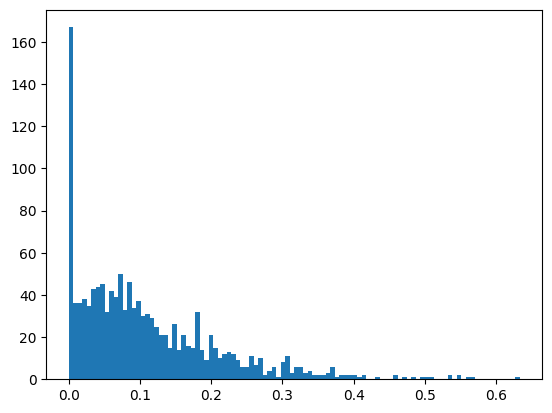

In [16]:
plt.hist(conf_scores_depths.numpy(), bins=100);

In [18]:
qhat_depth = torch.quantile(conf_scores_depths, 0.9)
qhat_depth
# Note: 2*qhat_depth = width of the confidence interval centered at the predicted depth 

tensor(0.2469)

### Calibrate Task 3

In [23]:
all_pred_logits_tensor = torch.from_numpy(np.concatenate(all_pred_logits, axis=0))
all_pred_logits_tensor.shape

torch.Size([1296, 100])

In [24]:
all_true_hor_inds_tensor = torch.from_numpy(np.concatenate(all_true_hor_inds, axis=0))
all_true_hor_inds_tensor.shape

torch.Size([1296])

In [25]:
import torch.nn.functional as F

all_pred_probs_tensor = F.softmax(all_pred_logits_tensor, dim=1)
all_pred_probs_tensor.shape

torch.Size([1296, 100])

In [26]:
prob_true_class = all_pred_probs_tensor[torch.arange(len(all_true_hor_inds_tensor)), all_true_hor_inds_tensor]
prob_true_class.shape

torch.Size([1296])

In [ ]:
qhat_horizon = torch.quantile(1 - prob_true_class, 0.90) # apply sample correction (n+1)/n ?
qhat_horizon

tensor(0.9941)

### Conformal Predictions on Test Set

In [19]:
all_pred_depths, all_true_depths   = [], []
all_pred_logits, all_true_hor_inds = [], []
for batch in test_loader:
    padded_images, image_mask, geotemp_features, padded_true_depths, padded_segments_tabulars_labels, padded_true_horizon_indices = batch
    padded_images, image_mask, geotemp_features, padded_true_depths, padded_segments_tabulars_labels, padded_true_horizon_indices = (
        padded_images.to(device),
        image_mask.to(device),
        geotemp_features.to(device),
        padded_true_depths.to(device),
        padded_segments_tabulars_labels.to(device),
        padded_true_horizon_indices.to(device)
    )
    
    with torch.no_grad():
        
        # Mask for valid indices
        mask = padded_true_horizon_indices != -1
        
        ### Predictions for all (sub)tasks
        padded_pred_depths, padded_pred_tabulars, padded_pred_logits = soilnet(
            padded_images,
            image_mask,
            geotemp_features[:, 1:], # 'index' column not used in model
            #padded_true_depths,             # use predicted depths when not training 
            #padded_segments_tabulars_labels # use predicted tabulars when not training
        )
        
        # Store predicted horizon logits and true indices
        pred_logits = padded_pred_logits.view(-1, padded_pred_logits.size(-1))[mask.view(-1)]  # Apply mask
        all_pred_logits.append(pred_logits.cpu().numpy())
        
        true_horizon_indices = padded_true_horizon_indices.view(-1)[padded_true_horizon_indices.view(-1) != -1]
        all_true_hor_inds.append(true_horizon_indices.cpu().numpy())
        
        # Store predicted and true depths
        all_pred_depths.append(padded_pred_depths.cpu().numpy())
        all_true_depths.append(padded_true_depths.cpu().numpy())

#### Confidence Intervals Task 1

In [20]:
all_pred_depths = np.concatenate(all_pred_depths, axis=0)
all_pred_depths.shape

(328, 8)

In [ ]:
trimmed_pred_depths = []
for sublist in all_pred_depths.tolist():
    # Remove trailing 1.0's, keep one if present
    i = len(sublist) - 1
    while i > 0 and sublist[i] == 1.0 and sublist[i-1] == 1.0:
        i -= 1
    trimmed_pred_depths.append(sublist[:i+1])
#trimmed_pred_depths

In [24]:
trimmed_pred_depths[-1]

[0.21693088114261627,
 0.48229312896728516,
 0.7399629950523376,
 0.9801235198974609,
 1.0]

In [26]:
padded_images[-1].shape

torch.Size([3, 4855, 2521])

In [29]:
image_mask[-1].shape

torch.Size([1, 4855, 2521])

In [43]:
_, row_inds, col_inds = np.where(image_mask[-1].cpu().numpy() == True)
row_ind, col_ind = max(row_inds), max(col_inds)

In [49]:
orig_img = padded_images[-1][:, :row_ind, :col_ind]
orig_img.shape

torch.Size([3, 3460, 2229])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


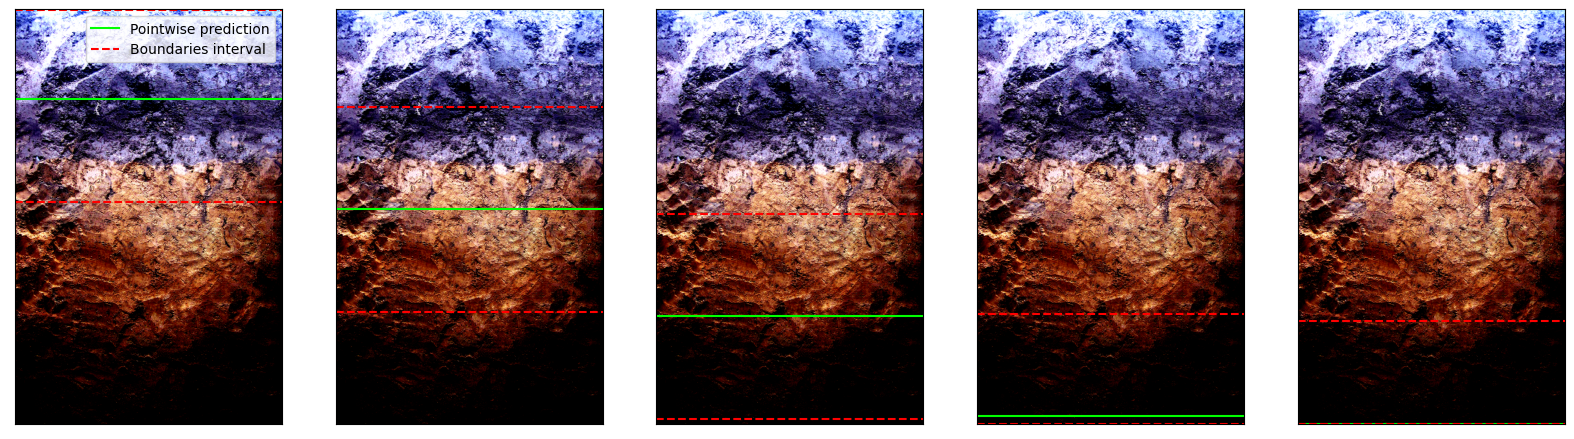

In [ ]:
# Plot prediction intervals for all pointwise predicted markers
plt.figure(figsize=(20, 14))
img_height = orig_img.shape[1]
eps = 0.001
for ind in range(len(trimmed_pred_depths[-1])):
    
    plt.subplot(1, len(trimmed_pred_depths[-1]), ind+1)
    plt.imshow(orig_img.permute(1, 2, 0).cpu().numpy())
    
    pred_depth = np.min((trimmed_pred_depths[-1][ind], 1.0-eps)) # subtract an epsilon here to avoid plot artifacts at the final prediction
    # Get the confidence interval width
    lower = np.max((eps, pred_depth - qhat_depth))
    upper = np.min((pred_depth + qhat_depth, 1.0-eps))

    # Convert normalized depths to pixel coordinates
    plt.axhline(y=pred_depth * img_height, color='lime', linestyle='-')
    plt.axhline(y=lower * img_height, color='red', linestyle='--')
    plt.axhline(y=upper * img_height, color='red', linestyle='--')
    if ind == 0: plt.legend(['Pointwise prediction', 'Boundaries interval'])
    plt.xticks([]);plt.yticks([])
plt.show()

#### Prediction Sets Task 3

In [29]:
all_pred_logits_tensor = torch.from_numpy(np.concatenate(all_pred_logits, axis=0))
all_pred_logits_tensor.shape

torch.Size([1335, 100])

In [30]:
all_pred_probs_tensor = F.softmax(all_pred_logits_tensor, dim=1)
all_pred_probs_tensor.shape

torch.Size([1335, 100])

In [ ]:
# Predict label sets on the test set
test_prediction_sets = (1 - all_pred_probs_tensor <= qhat_horizon) 

In [32]:
test_prediction_sets

tensor([[False, False, False,  ..., False, False, False],
        [False,  True,  True,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [ True, False,  True,  ..., False, False, False],
        [ True, False,  True,  ..., False, False, False]])

In [33]:
test_prediction_sets.shape

torch.Size([1335, 100])

In [ ]:
# Get the mapping from index to label
horizon_labels = dataprocessor.embeddings_dict['ind2label']

# For each row in test_prediction_sets, get the list of labels where the prediction set is True
predicted_label_lists = [
    [horizon_labels[i] for i, is_in_set in enumerate(row) if is_in_set]
    for row in test_prediction_sets.cpu().numpy()
]

In [37]:
for pred_sets in predicted_label_lists:
    print(pred_sets)

['Ap', 'Ah']
['Ael', 'Sd', 'Axh', 'Bhv', 'Bvt', 'Ap', 'Acp', 'Bv', 'elC', 'M.', 'Sw', 'Bt', 'Btv', 'R.', 'Al', 'Sw-Bv', 'Bv-Sw', 'Al-Sw', 'Al-Bv', 'Sw-Al', 'Sd-Bt', 'Sw-M', 'Sw-Ap', 'Bv-Ael']
['ilC', 'Ael', 'Sd', 'Cv', 'Axh', 'Bvt', 'Go', 'Ssw', 'Bv', 'elC', 'lC', 'M.', 'Sw', 'Bt', 'Btv', 'elCc', 'Al', 'Sw-Bv', 'Bv-ilC', 'Bv-Sw', 'Bt-Sd', 'Bv-Cv', 'Sd-ilC', 'Al-Sw', 'Al-Bv', 'Sw-Al', 'Sd-Bt', 'Ael-Bt', 'Al-Bt', 'P-Sd']
['ilC', 'Sd', 'C.', 'Cv', 'Bvt', 'Go', 'Bv', 'elC', 'lC', 'Sw', 'Bt', 'Btv', 'elCc', 'Bv-Sw', 'Bt-Sd', 'Sd-ilC', 'Sd-Bt', 'P-Sd', 'Sd-lC']
['Ap', 'Ah']
['E.', 'Go', 'Ap', 'M.', 'Ah', 'M-Go']
['Ael', 'Sd', 'E.', 'aelC', 'Gro', 'Go', 'Ap', 'Bv', 'Bhs', 'Gr', 'Gkso', 'Gor', 'M.', 'Sw', 'R.', 'tGo', 'M-Go', 'Go-M']
['Sd', 'Gro', 'Go', 'Gr', 'Gkso', 'Gor', 'M-Go']
['Sd', 'Gro', 'Go', 'tGr', 'Gr', 'Gkso', 'Gor', 'M-Go']
['Sd', 'Gro', 'Go', 'tGr', 'Gr', 'Gkso', 'Gor', 'M-Go']
['ilC', 'Sd', 'Gro', 'Go', 'Gw', 'tGr', 'Gr', 'Gkso', 'Gor', 'M-Go']
['Ap', 'Ah']
['Ap', 'Bv', 'M.', 'S